# Week 8 - Model Metrics

Additional References:
- [Google Colab](https://colab.research.google.com/?utm_source=scs-index)
- [Pandas Documentation](https://pandas.pydata.org/docs/index.html)
- [Python for Beginners](https://www.python.org/about/gettingstarted/)

## Business Understanding

-  Bank Churn: Customers that defaulted from the credit card company.
- Goal: Understand customers based on bank churn data.

## Data Understanding

### Preliminaries

Step 1. Set up project directory.

```
lastname_project
|---data                          # Directory for source data (*.csv)
    |---churn_test_20240126.csv   # Source data
|---notebook                      # Directory for Colab Notebook (*.ipynb)
    |---lastname_project.ipynb    # Colab Notebook
```

Step 2. Move source data into your Google Drive.

Step 3. Mount your Google Drive.

### Packages

In [7]:
#### Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Source Data

In [9]:
#### Read data
pdf = pd.read_csv('/content/drive/MyDrive/Work/PORTFOLIO/DATA ANALYTICS/Machine Learning Endeavor (Customer Churn)/data/churn_train_20240309.csv')

In [10]:
#### Basic information
pdf.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8101 entries, 0 to 8100
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Attrition_Flag          8101 non-null   int64  
 1   Marital_Status          8101 non-null   object 
 2   Education_Level         8101 non-null   object 
 3   Customer_Age            8101 non-null   int64  
 4   Dependent_count         8101 non-null   int64  
 5   Months_Inactive_12_mon  8101 non-null   int64  
 6   Credit_Limit            8101 non-null   float64
 7   Total_Revolving_Bal     8101 non-null   int64  
 8   Total_Amt_Chng_Q4_Q1    8101 non-null   float64
dtypes: float64(2), int64(5), object(2)
memory usage: 569.7+ KB


In [11]:
#### Shape
pdf.shape

(8101, 9)

In [12]:
#### Null
pdf.isnull().sum()

,0
Attrition_Flag,0
Marital_Status,0
Education_Level,0
Customer_Age,0
Dependent_count,0
Months_Inactive_12_mon,0
Credit_Limit,0
Total_Revolving_Bal,0
Total_Amt_Chng_Q4_Q1,0


In [13]:
### Duplicate
pdf.duplicated().sum()

np.int64(0)

In [14]:
#### First 5 rows
pdf.head()

,Attrition_Flag,Marital_Status,Education_Level,Customer_Age,Dependent_count,Months_Inactive_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1
0,0,Single,Unknown,54,1,3,3723.0,1728,0.595
1,1,Married,High School,58,4,4,5396.0,1803,0.493
2,0,Single,Unknown,45,4,1,15987.0,1648,0.732
3,0,Single,Graduate,34,2,3,3625.0,2517,1.158
4,0,Married,High School,49,2,3,2720.0,1926,0.602


### Numeric features

In [15]:
#### Get descriptive statistics
pdf.describe()

,Attrition_Flag,Customer_Age,Dependent_count,Months_Inactive_12_mon,Credit_Limit,Total_Revolving_Bal,Total_Amt_Chng_Q4_Q1
count,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000,8101.000000
mean,0.160474,46.306382,2.334773,2.346871,8636.548068,1160.382792,0.760809
std,0.367068,8.022527,1.289564,1.014177,9086.419557,815.504293,0.216668
min,0.000000,26.000000,0.000000,0.000000,1438.300000,0.000000,0.000000
25%,0.000000,41.000000,1.000000,2.000000,2555.000000,326.000000,0.632000
50%,0.000000,46.000000,2.000000,2.000000,4549.000000,1273.000000,0.738000
75%,0.000000,52.000000,3.000000,3.000000,11128.000000,1782.000000,0.859000
max,1.000000,70.000000,5.000000,6.000000,34516.000000,2517.000000,2.675000


### Target feature

In [16]:
#### Count Attrition_Flag by value
pdf['Attrition_Flag'].value_counts()

,count
Attrition_Flag,
0,6801
1,1300


<Axes: xlabel='Attrition_Flag'>

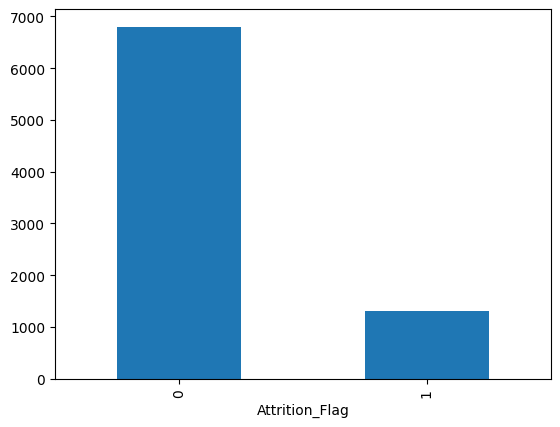

In [17]:
#### Plot Attrition_Flag bar graph
pdf['Attrition_Flag'].value_counts().plot(kind='bar')

## Data Preparation

In [18]:
data = pdf.copy()

In [19]:
# Separate target variable and features
y = data['Attrition_Flag']
X = data.drop(['Attrition_Flag'], axis=1)

In [20]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Modeling

In [21]:
X_train.columns

Index(['Marital_Status', 'Education_Level', 'Customer_Age', 'Dependent_count',
       'Months_Inactive_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Total_Amt_Chng_Q4_Q1'],
      dtype='object')

In [22]:
# Model
estimator = LogisticRegression()

# Create transformers for categorical and numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat_onehot', OneHotEncoder(handle_unknown='ignore'), ['Education_Level', 'Marital_Status'])
        ,('num_standard', StandardScaler(), ['Total_Amt_Chng_Q4_Q1', 'Total_Revolving_Bal'])
        ,('num_minmax', MinMaxScaler(), ['Dependent_count', 'Customer_Age'])
    ],
    remainder="passthrough",
)

# Create a logistic regression model using a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor)
    ,('estimator', estimator)
])

# Fit training data into model pipeline
pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppr

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Education_Level',
                                                   'Marital_Status']),
                                                 ('num_standard',
                                                  StandardScaler(),
                                                  ['Total_Amt_Chng_Q4_Q1',
                                                   'Total_Revolving_Bal']),
                                                 ('num_minmax', MinMaxScaler(),
                                                  ['Dependent_count',
                                                   'Customer_Age'])])),
                ('estimator', LogisticRegression())])

Accuracy: 0.84
Precision: 0.59
Recall: 0.09

Confusion Matrix:
[[5352   63]
 [ 973   92]]


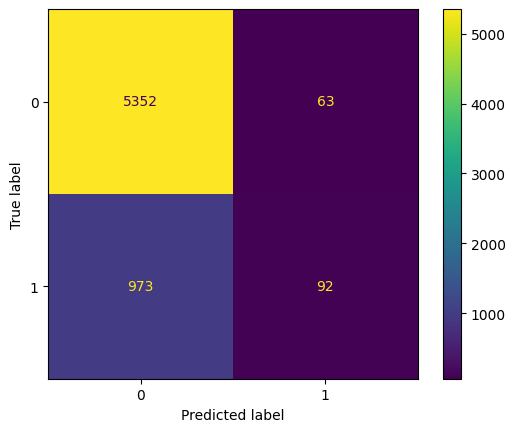

In [23]:
# Make predictions on the train set
y_pred_train = pipeline.predict(X_train)

# Evaluate the model
accuracy_train = accuracy_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train)
recall_train = recall_score(y_train, y_pred_train)
cm_train = confusion_matrix(y_train, y_pred_train)

print(f"Accuracy: {accuracy_train:.2f}")
print(f"Precision: {precision_train:.2f}")
print(f"Recall: {recall_train:.2f}")
print(f"\nConfusion Matrix:")
print(cm_train)

cmd_train = ConfusionMatrixDisplay(cm_train)
cmd_train.plot()

Accuracy: 0.86
Precision: 0.57
Recall: 0.09

Confusion Matrix:
[[1370   16]
 [ 214   21]]


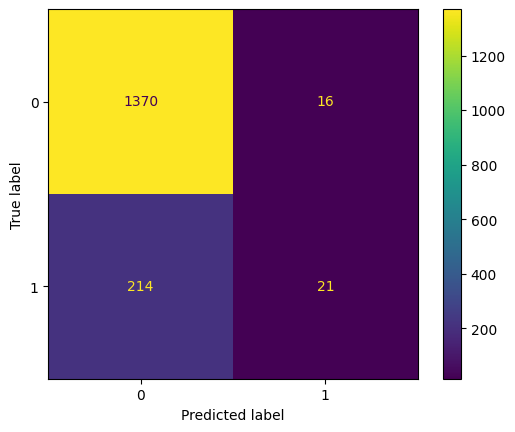

In [24]:
# Make predictions on the test set
y_pred_test = pipeline.predict(X_test)

# Evaluate the model
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
cm_test = confusion_matrix(y_test, y_pred_test)

print(f"Accuracy: {accuracy_test:.2f}")
print(f"Precision: {precision_test:.2f}")
print(f"Recall: {recall_test:.2f}")
print(f"\nConfusion Matrix:")
print(cm_test)

cmd_test = ConfusionMatrixDisplay(cm_test)
cmd_test.plot()